# HW4. Обучение Dyna-Q агента для стохастической среды


### Подготовка окружения и импорт библиотек


**Установка зависимостей**

In [1]:
# !pip install gymnasium


**Импорт библиотек**

In [2]:
import os
import sys
import PIL
import time
import json
import random
import numpy as np
import pandas as pd
import shutil as sh
from glob import glob
from pytz import timezone
from datetime import datetime
from collections import deque
from base64 import b64encode
from matplotlib import pyplot as plt
from IPython.display import display, clear_output, HTML
import seaborn as sns


In [3]:
import gymnasium as gym

### Настройка временной зоны


In [4]:
TZ = timezone('Europe/Moscow')

### Директории для экспериментов


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# env_dir = '.'
env_dir = '/content/drive/MyDrive/OTUS/RL/hw4'
scenarios_dir = os.path.join(env_dir, 'scenarios')


In [7]:
if not os.path.exists(scenarios_dir):
    os.makedirs(scenarios_dir)

### Вспомогательные функции


**Отображение состояния среды, сохранение записи эпизода, просмотр записи эпизода**

In [8]:
def display_state(state):
    plt.figure(figsize=(6, 6))
    plt.imshow(state)
    plt.axis('off')


def record_episode(eps_frames, records_dir, agent_name, exp_id, eps_num):
    record_path = os.path.join(records_dir, f'{agent_name}_{exp_id}_eps-{eps_num}.mp4')
    eps_frame_dir = 'episode_frames'
    os.mkdir(eps_frame_dir)

    for i, frame  in enumerate(eps_frames):
        PIL.Image.fromarray(frame).save(os.path.join(eps_frame_dir, f'frame-{i+1}.png'))

    os.system(f'ffmpeg -r 2 -i {eps_frame_dir}/frame-%1d.png -vcodec libx264 -b 10M -y "{record_path}"');
    sh.rmtree(eps_frame_dir)


def show_episode_records(records_dir):
    record_paths = glob(os.path.join(records_dir, "*.mp4"))
    html_str = ''
    for i, record_path in enumerate(record_paths):
        mp4 = open(record_path, 'rb').read()
        data = f"data:video/mp4;base64,{b64encode(mp4).decode()}"
        html_str += f'EPISODE # {i+1}<br><video width=500 controls><source src="{data}" type="video/mp4"></video><br><br>'
    return HTML(html_str)


**Создание директорий для логирования результатов, сохрание параметров и метрик экспериментов**

In [9]:
def create_exp_dirs(scenarios_dir, exp_params):
    dirs = dict()
    dirs['exp'] = os.path.join(scenarios_dir, exp_params["scenario_name"], exp_params["algorithm_name"], exp_params["exp_id"])
    dirs['training'] = os.path.join(dirs['exp'], 'training')
    dirs['evaluation'] = os.path.join(dirs['exp'], 'evaluation')
    os.makedirs(dirs['training'], exist_ok=True)
    os.makedirs(dirs['evaluation'], exist_ok=True)
    return dirs


def save_exp_params(params, exp_dir):
    params_path = os.path.join(exp_dir, 'experiment_params.json')
    with open(params_path, 'w') as f:
        json.dump(params, f)


def save_metrics(metrics, metrics_type, train_eps_dir):
    metrics_path = os.path.join(train_eps_dir, f'{metrics_type}_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f)

**Построение графика процесса валидации для выбранных экспериментов**

In [10]:
def display_validation_plot(scenarios_dir, scenario_name, exp_ids):
    fig = plt.figure(figsize=(10, 6))
    earliest_validation_eps = np.inf
    max_training_eps_count = 0

    for display_name, exp_meta in exp_ids.items():
        if isinstance(exp_meta, dict):
            model_name = exp_meta['algorithm_name']
            model_exp_ids = exp_meta['exp_ids']
        else:
            model_name = display_name
            model_exp_ids = exp_meta

        for exp_id in model_exp_ids:
            exp_dir = os.path.join(scenarios_dir, scenario_name, model_name, exp_id)
            exp_params_path = os.path.join(exp_dir, 'experiment_params.json')
            training_dir = os.path.join(exp_dir, 'training')

            with open(exp_params_path, 'r') as f:
                exp_params = json.load(f)

            total_eps_count = exp_params['training']['episode_count']
            validation_step = exp_params['validation']['validate_agent_every_n_eps']

            if total_eps_count > max_training_eps_count:
                max_training_eps_count = total_eps_count
            if validation_step < earliest_validation_eps:
                earliest_validation_eps = validation_step

            exp_win_shares = []
            for iter_name in os.listdir(training_dir):
                iter_metrics_path = os.path.join(training_dir, iter_name, 'training_iter_metrics.json')
                with open(iter_metrics_path, 'r') as f:
                    iter_metrics = json.load(f)
                exp_win_shares.append(iter_metrics['win_share'])

            iter_means = np.mean(exp_win_shares, axis=0).round(3)
            iter_stds = np.std(exp_win_shares, axis=0).round(3)
            std_bounds = np.array([[avg - std, avg + std] for avg, std in zip(iter_means, iter_stds)])
            validation_steps = range(validation_step, total_eps_count + validation_step, validation_step)

            plt.plot(validation_steps, iter_means, label=f'{display_name} ({exp_id})')
            plt.fill_between(validation_steps, std_bounds[:, 0], std_bounds[:, 1], alpha=.3)

    plt.xlim(earliest_validation_eps, max_training_eps_count)
    plt.ylim(0, 1)
    plt.xlabel('Training episodes')
    plt.ylabel('Win share')
    plt.title(f'Comparative assessment of learning process ({scenario_name})')
    plt.legend(loc='upper left')
    plt.grid()

**Загрузка лучшего состояния агента по шагу обучения**


In [11]:
def load_best_agent_for_train_step(train_eps_num, iteration_count, training_dir, agent):
    best_iter_num = 1
    best_win_share = 0
    best_avg_step_count = 100
    for iter_num in range(1, iteration_count+1):
        iter_dir = os.path.join(training_dir, f'iter-{iter_num}')
        eps_dir = os.path.join(iter_dir, f'eps-{train_eps_num}')
        val_metrics_path = os.path.join(eps_dir, 'validation_metrics.json')
        with open(val_metrics_path, 'r') as f:
            val_metrics = json.load(f)
        if val_metrics['win_share'] > best_win_share and val_metrics['avg_step_count'] < best_avg_step_count:
            best_iter_num = iter_num
            best_win_share = val_metrics['win_share']
            best_avg_step_count = val_metrics['avg_step_count']

    agent_state_dir = os.path.join(training_dir, f'iter-{best_iter_num}', f'eps-{train_eps_num}')
    agent.load_agent_state(agent_state_dir)

## 1. Знакомство со средой


In [12]:
MAP_SIZE = 8
STOCHASTIC_ENV = True
ACTION_MAP = {
    'L': 0,
    'D': 1,
    'R': 2,
    'U': 3
}

def create_environment(map_size, stochastic_env):
    return gym.make('FrozenLake-v1', map_name=f'{map_size}x{map_size}', is_slippery=stochastic_env, render_mode='rgb_array')


### Создание стохастической версии Frozen Lake 8x8


Current state: 0


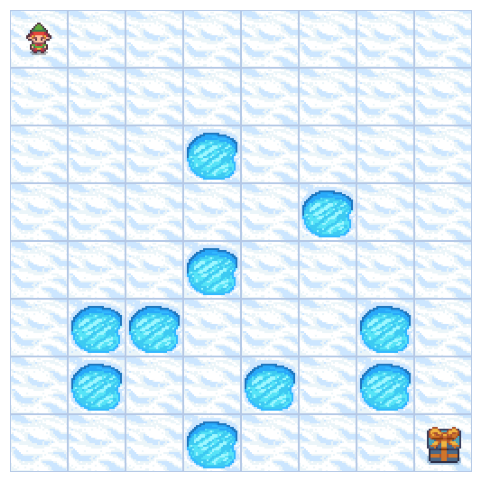

In [13]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
state, info = env.reset()
state_rgb = env.render()

print(f'Current state: {state}')
display_state(state_rgb)

### Проверка одного шага среды


Current state: 1
Reward: 0
Done: (False, False)


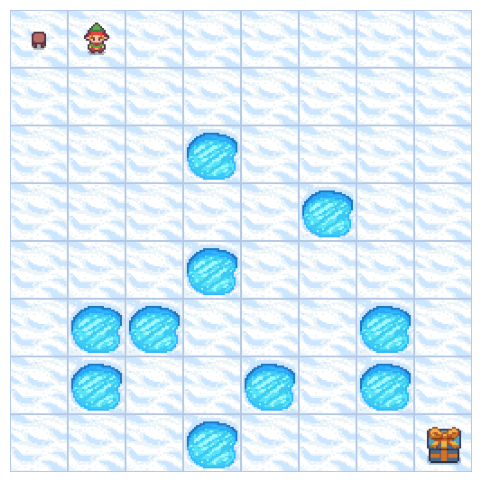

In [14]:
action_name = 'D'
action = ACTION_MAP[action_name]

next_state, reward, terminated, truncated, info = env.step(action)
next_state_rgb = env.render()

print(f'Current state: {next_state}\nReward: {reward}\nDone: {terminated, truncated}')
display_state(next_state_rgb)

In [15]:
env.close()

## 2. Базовый уровень: случайный агент


### Класс случайного агента


In [16]:
class RandomAgent:

  def __init__(self, env, params):
      self._env = env
      self._params = params

  @property
  def name(self):
      return f"{self._params['algorithm_name']}_agent"

  def choose_action(self, state, mode='exploitation'):
      return self._env.action_space.sample()

### Запуск эпизода и оценка агента


In [17]:
def run_episode(env, agent):
    state, info = env.reset()
    step_count = 0
    frames = list()
    done = False

    while not done:
        action = agent.choose_action(state, mode='exploitation')
        next_state, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
        state = next_state
        step_count += 1

    frames.extend([env.render()] * 3)
    return state, step_count, frames


def evaluate_agent(env, agent, exp_params, exp_dirs):
    for eps_num in range(1, exp_params['evaluation']['episode_count'] + 1):
        eps_final_state, eps_step_count, eps_frames = run_episode(env, agent)
        record_episode(eps_frames, exp_dirs['evaluation'], exp_params['algorithm_name'], exp_params['exp_id'], eps_num)

        print(f'EPISODE # {eps_num}')
        if eps_final_state == env.observation_space.n - 1:
            print('Agent reached the Goal 🏆')
        else:
            print('Agent was defeated ☠️')
        print(f'Number of steps: {eps_step_count}')
        print('-' * 50)

### Параметры baseline-эксперимента


In [18]:
exp_params = {
    'scenario_name': f'{MAP_SIZE}x{MAP_SIZE}_{"stochastic" if STOCHASTIC_ENV else "deterministic"}',
    'algorithm_name': 'random',
    'exp_id': 'random_baseline',
    'seed': 21,
    'evaluation': {
        'episode_count': 3
    }
}

exp_dirs = create_exp_dirs(scenarios_dir, exp_params)
save_exp_params(exp_params, exp_dirs['exp'])


### Оценка случайной стратегии


In [19]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
random_agent = RandomAgent(env, exp_params)
evaluate_agent(env, random_agent, exp_params, exp_dirs)
env.close()

EPISODE # 1
Agent was defeated ☠️
Number of steps: 10
--------------------------------------------------
EPISODE # 2
Agent was defeated ☠️
Number of steps: 11
--------------------------------------------------
EPISODE # 3
Agent was defeated ☠️
Number of steps: 51
--------------------------------------------------


In [20]:
show_episode_records(exp_dirs['evaluation'])

## 3. Табличный Q-learning в стохастической среде


### Реализация Q-агента


In [21]:
class QAgent:

    def __init__(self, env, params):
        self._env = env
        self._params = params
        self._epsilon = params['training']['epsilon']
        self._qtable = np.zeros((env.observation_space.n, env.action_space.n))
        self._action_arrow_map = { 0: '', 1: '←', 2: '↓', 3: '→', 4: '↑' }

    @property
    def name(self):
        return f"{self._params['algorithm_name']}_agent"

    @property
    def exploration_level(self):
        return self._epsilon


    def choose_action(self, state, mode='exploitation'):
        if mode == 'exploration':
          if np.random.rand() < self._epsilon:
              return self._env.action_space.sample()

        return np.argmax(self._qtable[state, :])


    def learn(self, state, action, next_state, reward):
        target = reward + self._params['training']['gamma'] * np.max(self._qtable[next_state, :])
        self._qtable[state, action] = self._qtable[state, action] + \
                                      self._params['training']['learning_rate'] * (target - self._qtable[state, action])


    def decrease_exploration_level(self):
        if self._epsilon > self._params['training']['epsilon_min']:
            self._epsilon *= self._params['training']['epsilon_decay_rate']


    def display_q_table(self):
        self._prepare_q_table()


    def save_q_table_as_plot(self, eps_dir):
        q_table_plot = self._prepare_q_table()
        q_table_plot_path = os.path.join(eps_dir, 'qtable.png')
        q_table_plot.savefig(q_table_plot_path, bbox_inches='tight')
        plt.close(q_table_plot)


    def save_agent_state(self, eps_dir):
        qtable_path = os.path.join(eps_dir, 'qtable.npy')
        np.save(qtable_path, self._qtable)


    def load_agent_state(self, eps_dir):
        qtable_path = os.path.join(eps_dir, 'qtable.npy')
        self._qtable = np.load(qtable_path, allow_pickle=True)


    def _prepare_q_table(self):
        greedy_values = np.max(self._qtable, axis=1).reshape(MAP_SIZE, MAP_SIZE)
        greedy_actions = np.argmax(np.hstack((np.zeros((self._env.observation_space.n, 1)), self._qtable)), axis=1)
        greedy_actions_arrows = np.array(list(map(lambda x: '' if x == 0 else self._action_arrow_map[x], greedy_actions))).reshape(MAP_SIZE, MAP_SIZE)

        fig = plt.figure()
        sns.heatmap(greedy_values,
                    annot=greedy_actions_arrows,
                    annot_kws={"fontsize": 16},
                    fmt = '',
                    cmap="YlGnBu",
                    linewidths=.5)
        plt.axis('off')
        return fig


### Обучение и валидация


In [22]:
def train_agent(env, agent, exp_params, exp_dirs, enable_eps_recording):
    random.seed(exp_params['seed'])
    np.random.seed(exp_params['seed'])

    train_iter_count = len(os.listdir(exp_dirs['training']))
    train_iter_dir = os.path.join(exp_dirs['training'], f'iter-{train_iter_count+1}')
    os.mkdir(train_iter_dir)

    training_eps_count = exp_params['training']['episode_count']
    validate_agent_every_n_eps = exp_params['validation']['validate_agent_every_n_eps']
    validation_eps_count = exp_params['validation']['episode_count']

    train_metrics = {
        'total_eps_count': training_eps_count,
        'validation_step': validate_agent_every_n_eps,
        'win_share': []
    }

    for eps_num in range(1, training_eps_count + 1):
        state, info = env.reset()
        done = False

        while not done:
            action = agent.choose_action(state, mode='exploration')
            next_state, reward, terminated, truncated, info = env.step(action)
            agent.learn(state, action, next_state, reward)
            done = terminated or truncated
            state = next_state

        agent.decrease_exploration_level()

        if eps_num % validate_agent_every_n_eps == 0:
            eps_dir = os.path.join(train_iter_dir, f'eps-{eps_num}')
            os.mkdir(eps_dir)

            val_metrics = validate_agent(env, agent, exp_params, eps_dir, enable_eps_recording)
            train_metrics['win_share'].append(val_metrics['win_share'])
            agent.save_q_table_as_plot(eps_dir)
            agent.save_agent_state(eps_dir)

            print(f"EPISODE # {eps_num} / {training_eps_count}")
            print(f"Win share ({validation_eps_count} eps): {val_metrics['win_share']}")
            print(f"Avg step count ({validation_eps_count} eps): {val_metrics['avg_step_count']}")
            print(f"Aget exploration level (epsilon): {val_metrics['exploration_level']}")
            print('-' * 50)

    save_metrics(train_metrics, 'training_iter', train_iter_dir)
    return train_metrics


def validate_agent(env, agent, exp_params, train_eps_dir, enable_eps_recording):
    validation_eps_count = exp_params['validation']['episode_count']
    won_eps_count = 0
    eps_step_counts = list()

    for eps_num in range(1, validation_eps_count + 1):
        eps_final_state, eps_step_count, eps_frames = run_episode(env, agent)
        if eps_final_state == env.observation_space.n - 1:
            won_eps_count += 1
        eps_step_counts.append(eps_step_count)
        if enable_eps_recording:
            record_episode(eps_frames, train_eps_dir, exp_params['algorithm_name'], exp_params['exp_id'], eps_num)

    val_metrics = {
        'win_share': round(won_eps_count / validation_eps_count, 3),
        'avg_step_count': round(sum(eps_step_counts) / validation_eps_count, 3),
        'exploration_level': round(agent.exploration_level, 3)
    }

    save_metrics(val_metrics, 'validation', train_eps_dir)
    return val_metrics

### Параметры обучения Q-агента


In [23]:
exp_params = {
    'scenario_name': f'{MAP_SIZE}x{MAP_SIZE}_{"stochastic" if STOCHASTIC_ENV else "deterministic"}',
    'algorithm_name': 'qtable',
    'exp_id': 'q_agent_stochastic',
    'seed': 21,
    'training': {
        'iteration_count': 5,
        'episode_count': 5000,
        'learning_rate': 0.05,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_min': 0.01,
        'epsilon_decay_rate': 0.99995
    },
    'validation': {
        'validate_agent_every_n_eps': 500,
        'episode_count': 10
    },
    'evaluation': {
        'episode_count': 3
    }
}

exp_dirs = create_exp_dirs(scenarios_dir, exp_params)
save_exp_params(exp_params, exp_dirs['exp'])


### Обучение Q-агента


In [24]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)

for iter_num in range(1, exp_params['training']['iteration_count']+1):
    print(f'TRAINING ITERATION # {iter_num}\n')
    qtable_agent = QAgent(env, exp_params)
    train_agent(env, qtable_agent, exp_params, exp_dirs, enable_eps_recording=True)
    if iter_num != exp_params['training']['iteration_count']:
        clear_output()

env.close()

TRAINING ITERATION # 5

EPISODE # 500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.975
--------------------------------------------------
EPISODE # 1000 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.951
--------------------------------------------------
EPISODE # 1500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 22.2
Aget exploration level (epsilon): 0.928
--------------------------------------------------
EPISODE # 2000 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 32.1
Aget exploration level (epsilon): 0.905
--------------------------------------------------
EPISODE # 2500 / 5000
Win share (10 eps): 0.1
Avg step count (10 eps): 63.6
Aget exploration level (epsilon): 0.882
--------------------------------------------------
EPISODE # 3000 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 39.6
Aget exploration level (epsilon): 0.861
------------------------

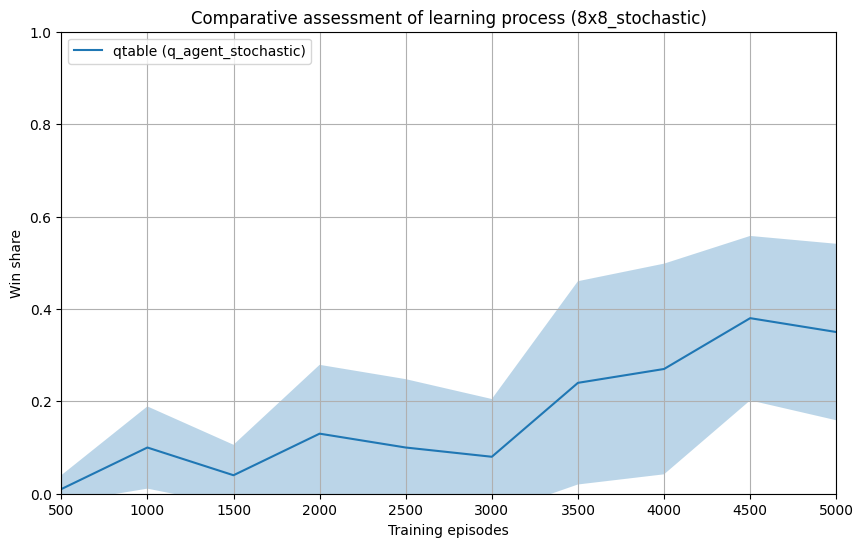

In [25]:
scenario_name = exp_params['scenario_name']
exp_ids = {
    exp_params['algorithm_name']: [exp_params['exp_id']]
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)

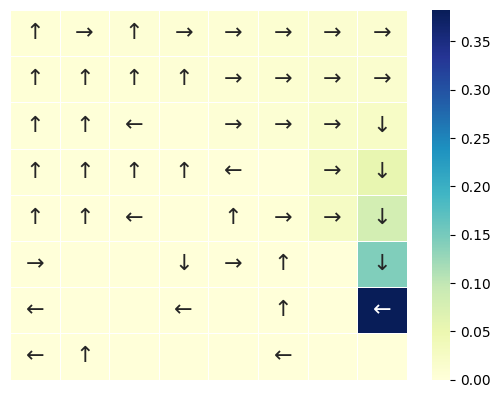

In [26]:
qtable_agent.display_q_table()

### Оценка Q-агента


In [27]:
train_eps_num = 3500

load_best_agent_for_train_step(train_eps_num,
                               exp_params['training']['iteration_count'],
                               exp_dirs['training'],
                               qtable_agent)

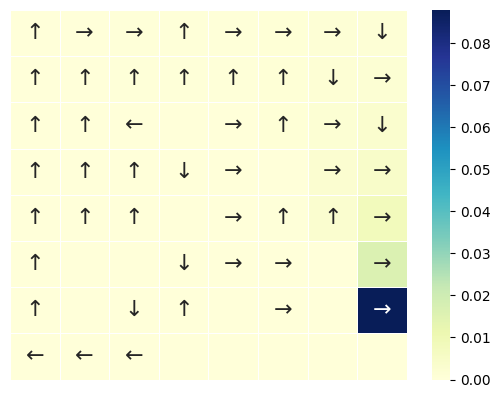

In [28]:
qtable_agent.display_q_table()

In [29]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
evaluate_agent(env, qtable_agent, exp_params, exp_dirs)
env.close()

EPISODE # 1
Agent was defeated ☠️
Number of steps: 100
--------------------------------------------------
EPISODE # 2
Agent reached the Goal 🏆
Number of steps: 28
--------------------------------------------------
EPISODE # 3
Agent reached the Goal 🏆
Number of steps: 55
--------------------------------------------------


In [30]:
show_episode_records(exp_dirs['evaluation'])

## 4. Dyna-Q со стохастической моделью среды


In [31]:
class DynaQAgent:

    def __init__(self, env, env_model_cls, params):
        self._env = env
        self._params = params
        self._epsilon = params['training']['epsilon']
        self._qtable = np.zeros((env.observation_space.n, env.action_space.n))
        self._model = env_model_cls(env.observation_space.n, env.action_space.n)
        self._action_arrow_map = { 0: '', 1: '←', 2: '↓', 3: '→', 4: '↑' }

    @property
    def name(self):
        return f"{self._params['algorithm_name']}_agent"

    @property
    def exploration_level(self):
        return self._epsilon


    def choose_action(self, state, mode='exploitation'):
        if mode == 'exploration':
          if np.random.rand() < self._epsilon:
              return self._env.action_space.sample()

        return np.argmax(self._qtable[state, :])


    def learn(self, state, action, next_state, reward):
        self._learn(state, action, next_state, reward)
        self._update_model(state, action, next_state, reward)
        self._planning(self._params['training']['planning_steps'])


    def decrease_exploration_level(self):
        if self._epsilon > self._params['training']['epsilon_min']:
            self._epsilon *= self._params['training']['epsilon_decay_rate']


    def display_q_table(self):
        self._prepare_q_table()


    def save_q_table_as_plot(self, eps_dir):
        q_table_plot = self._prepare_q_table()
        q_table_plot_path = os.path.join(eps_dir, 'qtable.png')
        q_table_plot.savefig(q_table_plot_path, bbox_inches='tight')
        plt.close(q_table_plot)


    def display_model(self):
        print(f'Transitions tabel:\n')
        self._model.display_transitions()
        print(f'\n\nRewards tabel:\n')
        self._model.display_rewards()


    def save_agent_state(self, state_dir):
        np.save(os.path.join(state_dir, 'qtable.npy'), self._qtable)
        np.save(os.path.join(state_dir, 'model_transitions.npy'), self._model.transitions)
        np.save(os.path.join(state_dir, 'model_rewards.npy'), self._model.rewards)


    def load_agent_state(self, state_dir):
        self._qtable = np.load(os.path.join(state_dir, 'qtable.npy'), allow_pickle=True)
        self._model.transitions = np.load(os.path.join(state_dir, 'model_transitions.npy'), allow_pickle=True)
        self._model.rewards = np.load(os.path.join(state_dir, 'model_rewards.npy'), allow_pickle=True)


    def _learn(self, state, action, next_state, reward):
        target = reward + self._params['training']['gamma'] * np.max(self._qtable[next_state, :])
        self._qtable[state, action] = self._qtable[state, action] + \
                                      self._params['training']['learning_rate'] * (target - self._qtable[state, action])


    def _update_model(self, state, action, next_state, reward):
        self._model.update(state, action, next_state, reward)


    def _planning(self, n_steps):
        for i in range(n_steps):
            state, action =  self._model.sample()
            next_state, reward = self._model.step(state, action)
            self._learn(state, action, next_state, reward)


    def _prepare_q_table(self):
        greedy_values = np.max(self._qtable, axis=1).reshape(MAP_SIZE, MAP_SIZE)
        greedy_actions = np.argmax(np.hstack((np.zeros((self._env.observation_space.n, 1)), self._qtable)), axis=1)
        greedy_actions_arrows = np.array(list(map(lambda x: '' if x == 0 else self._action_arrow_map[x], greedy_actions))).reshape(MAP_SIZE, MAP_SIZE)

        fig = plt.figure()
        sns.heatmap(greedy_values,
                    annot=greedy_actions_arrows,
                    annot_kws={"fontsize": 16},
                    fmt = '',
                    cmap="YlGnBu",
                    linewidths=.5)
        plt.axis('off')
        return fig


### Стохастическая модель среды


In [32]:
class StochasticEnvModel:
    """
    Табличная модель для стохастической среды Frozen Lake.
    """

    def __init__(self, n_states, n_actions):
        self.n_states = n_states
        self.n_actions = n_actions

        self.transitions = np.empty((n_states, n_actions), dtype=object)
        self.rewards = np.empty((n_states, n_actions), dtype=object)

        self._observed_pairs = []
        self._observed_pairs_set = set()

        for state in range(n_states):
            for action in range(n_actions):
                self.transitions[state, action] = {}
                self.rewards[state, action] = {}


    def update(self, state, action, next_state, reward):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        reward = float(reward)

        if (state, action) not in self._observed_pairs_set:
            self._observed_pairs.append((state, action))
            self._observed_pairs_set.add((state, action))

        counts = self.transitions[state, action]
        counts[next_state] = counts.get(next_state, 0) + 1

        reward_stats = self.rewards[state, action]
        mean_reward, count = reward_stats.get(next_state, (0.0, 0))
        count += 1
        mean_reward += (reward - mean_reward) / count
        reward_stats[next_state] = (mean_reward, count)


    def sample(self):
        if not self._observed_pairs:
            self._restore_observed_pairs()
        return random.choice(self._observed_pairs)


    def step(self, state, action):
        counts = self.transitions[state, action]
        if not counts:
            return int(state), 0.0

        next_states = np.array(list(counts.keys()), dtype=int)
        weights = np.array(list(counts.values()), dtype=float)
        probabilities = weights / weights.sum()

        next_state = int(np.random.choice(next_states, p=probabilities))
        mean_reward, _ = self.rewards[state, action].get(next_state, (0.0, 0))
        return next_state, float(mean_reward)


    def display_transitions(self):
        table = np.empty((self.n_states, self.n_actions), dtype=object)
        for state in range(self.n_states):
            for action in range(self.n_actions):
                counts = self.transitions[state, action]
                if not counts:
                    table[state, action] = ''
                    continue
                total = sum(counts.values())
                probs = {next_state: round(count / total, 3) for next_state, count in sorted(counts.items())}
                table[state, action] = str(probs)

        display(HTML(pd.DataFrame(table, columns=['L', 'D', 'R', 'U']).T.to_html()))


    def display_rewards(self):
        table = np.empty((self.n_states, self.n_actions), dtype=object)
        for state in range(self.n_states):
            for action in range(self.n_actions):
                reward_stats = self.rewards[state, action]
                if not reward_stats:
                    table[state, action] = ''
                    continue
                means = {next_state: round(mean_reward, 3) for next_state, (mean_reward, _) in sorted(reward_stats.items())}
                table[state, action] = str(means)

        display(HTML(pd.DataFrame(table, columns=['L', 'D', 'R', 'U']).T.to_html()))


    def _restore_observed_pairs(self):
        self._observed_pairs = []
        self._observed_pairs_set = set()
        for state in range(self.n_states):
            for action in range(self.n_actions):
                if self.transitions[state, action]:
                    self._observed_pairs.append((state, action))
                    self._observed_pairs_set.add((state, action))


### Параметры обучения Dyna-Q


In [33]:
exp_params = {
    'scenario_name': f'{MAP_SIZE}x{MAP_SIZE}_{"stochastic" if STOCHASTIC_ENV else "deterministic"}',
    'algorithm_name': 'dynaq',
    'exp_id': 'dynaq_stochastic_ps30',
    'seed': 21,
    'training': {
        'iteration_count': 5,
        'episode_count': 5000,
        'learning_rate': 0.05,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_min': 0.01,
        'epsilon_decay_rate': 0.99995,
        'planning_steps': 30
    },
    'validation': {
        'validate_agent_every_n_eps': 500,
        'episode_count': 10
    },
    'evaluation': {
        'episode_count': 3
    }
}

exp_dirs = create_exp_dirs(scenarios_dir, exp_params)
save_exp_params(exp_params, exp_dirs['exp'])


### Обучение Dyna-Q


In [34]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)

for iter_num in range(1, exp_params['training']['iteration_count']+1):
    print(f'TRAINING ITERATION # {iter_num}\n')
    dynaq_agent = DynaQAgent(env, StochasticEnvModel, exp_params)
    train_agent(env, dynaq_agent, exp_params, exp_dirs, enable_eps_recording=True)
    if iter_num != exp_params['training']['iteration_count']:
        clear_output()

env.close()

TRAINING ITERATION # 5

EPISODE # 500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 63.5
Aget exploration level (epsilon): 0.975
--------------------------------------------------
EPISODE # 1000 / 5000
Win share (10 eps): 0.1
Avg step count (10 eps): 63.8
Aget exploration level (epsilon): 0.951
--------------------------------------------------
EPISODE # 1500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 66.0
Aget exploration level (epsilon): 0.928
--------------------------------------------------
EPISODE # 2000 / 5000
Win share (10 eps): 0.5
Avg step count (10 eps): 63.3
Aget exploration level (epsilon): 0.905
--------------------------------------------------
EPISODE # 2500 / 5000
Win share (10 eps): 0.6
Avg step count (10 eps): 64.3
Aget exploration level (epsilon): 0.882
--------------------------------------------------
EPISODE # 3000 / 5000
Win share (10 eps): 0.2
Avg step count (10 eps): 77.0
Aget exploration level (epsilon): 0.861
--------------------------

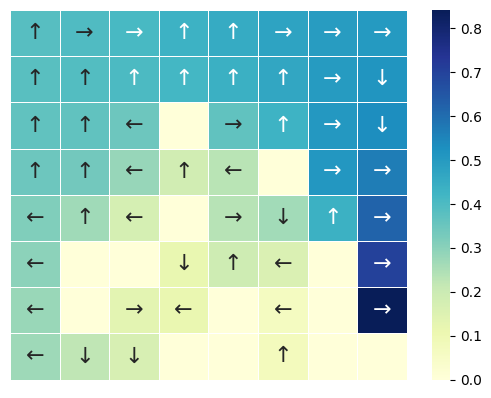

In [35]:
dynaq_agent.display_q_table()

In [36]:
dynaq_agent.display_model()

Transitions tabel:



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
L,"{0: 0.662, 8: 0.338}","{0: 0.333, 1: 0.336, 9: 0.331}","{1: 0.336, 2: 0.344, 10: 0.32}","{2: 0.33, 3: 0.329, 11: 0.341}","{3: 0.329, 4: 0.362, 12: 0.309}","{4: 0.343, 5: 0.309, 13: 0.349}","{5: 0.345, 6: 0.319, 14: 0.336}","{6: 0.274, 7: 0.344, 15: 0.382}","{0: 0.317, 8: 0.339, 16: 0.344}","{1: 0.328, 8: 0.336, 17: 0.336}","{2: 0.34, 9: 0.351, 18: 0.31}","{3: 0.339, 10: 0.323, 19: 0.338}","{4: 0.349, 11: 0.326, 20: 0.326}","{5: 0.299, 12: 0.349, 21: 0.352}","{6: 0.341, 13: 0.333, 22: 0.327}","{7: 0.32, 14: 0.318, 23: 0.362}","{8: 0.335, 16: 0.341, 24: 0.324}","{9: 0.319, 16: 0.338, 25: 0.343}","{10: 0.332, 17: 0.312, 26: 0.356}",,"{12: 0.317, 19: 0.34, 28: 0.343}","{13: 0.301, 20: 0.401, 29: 0.298}","{14: 0.308, 21: 0.375, 30: 0.317}","{15: 0.361, 22: 0.309, 31: 0.33}","{16: 0.361, 24: 0.316, 32: 0.323}","{17: 0.32, 24: 0.346, 33: 0.334}","{18: 0.292, 25: 0.372, 34: 0.336}","{19: 0.372, 26: 0.314, 35: 0.314}","{20: 0.317, 27: 0.35, 36: 0.333}",,"{22: 0.301, 29: 0.392, 38: 0.307}","{23: 0.325, 30: 0.33, 39: 0.345}","{24: 0.339, 32: 0.304, 40: 0.357}","{25: 0.34, 32: 0.362, 41: 0.298}","{26: 0.325, 33: 0.322, 42: 0.353}",,"{28: 0.25, 35: 0.417, 44: 0.333}","{29: 0.256, 36: 0.231, 45: 0.513}","{30: 0.284, 37: 0.324, 46: 0.392}","{31: 0.331, 38: 0.363, 47: 0.306}","{32: 0.36, 40: 0.29, 48: 0.349}",,,"{35: 0.5, 42: 0.333, 51: 0.167}","{36: 0.4, 43: 0.4, 52: 0.2}","{37: 0.259, 44: 0.37, 53: 0.37}",,"{39: 0.394, 46: 0.394, 55: 0.212}","{40: 0.34, 48: 0.335, 56: 0.325}",,"{42: 0.5, 49: 0.5}",{43: 1.0},,"{45: 0.4, 52: 0.6}",,"{47: 0.286, 54: 0.214, 63: 0.5}","{48: 0.274, 56: 0.726}","{49: 0.28, 56: 0.32, 57: 0.4}","{50: 0.364, 57: 0.091, 58: 0.545}",,{59: 1.0},"{60: 0.5, 61: 0.5}",,
D,"{0: 0.335, 1: 0.337, 8: 0.329}","{0: 0.339, 2: 0.335, 9: 0.326}","{1: 0.331, 3: 0.32, 10: 0.35}","{2: 0.34, 4: 0.326, 11: 0.334}","{3: 0.316, 5: 0.355, 12: 0.329}","{4: 0.318, 6: 0.351, 13: 0.332}","{5: 0.34, 7: 0.341, 14: 0.319}","{6: 0.318, 7: 0.318, 15: 0.364}","{8: 0.339, 9: 0.33, 16: 0.331}","{8: 0.347, 10: 0.335, 17: 0.318}","{9: 0.35, 11: 0.33, 18: 0.32}","{10: 0.338, 12: 0.313, 19: 0.349}","{11: 0.365, 13: 0.312, 20: 0.324}","{12: 0.307, 14: 0.34, 21: 0.353}","{13: 0.337, 15: 0.36, 22: 0.303}","{14: 0.324, 15: 0.353, 23: 0.323}","{16: 0.34, 17: 0.342, 24: 0.319}","{16: 0.316, 18: 0.331, 25: 0.352}","{17: 0.325, 19: 0.332, 26: 0.343}",,"{19: 0.309, 21: 0.333, 28: 0.358}","{20: 0.308, 22: 0.38, 29: 0.312}","{21: 0.308, 23: 0.354, 30: 0.338}","{22: 0.324, 23: 0.32, 31: 0.357}","{24: 0.343, 25: 0.33, 32: 0.326}","{24: 0.316, 26: 0.348, 33: 0.336}","{25: 0.344, 27: 0.332, 34: 0.324}","{26: 0.369, 28: 0.323, 35: 0.309}","{27: 0.29, 29: 0.382, 36: 0.328}",,"{29: 0.322, 31: 0.252, 38: 0.427}","{30: 0.341, 31: 0.345, 39: 0.314}","{32: 0.326, 33: 0.349, 40: 0.324}","{32: 0.278, 34: 0.34, 41: 0.382}","{33: 0.316, 35: 0.346, 42: 0.338}",,"{35: 0.312, 37: 0.354, 44: 0.333}","{36: 0.348, 38: 0.283, 45: 0.37}","{37: 0.292, 39: 0.333, 46: 0.375}","{38: 0.345, 39: 0.379, 47: 0.276}","{40: 0.338, 41: 0.278, 48: 0.384}",,,"{42: 0.333, 44: 0.333, 51: 0.333}","{43: 0.222, 45: 0.5, 52: 0.278}","{44: 0.167, 46: 0.5, 53: 0.333}",,"{46: 0.286, 47: 0.367, 55: 0.347}","{48: 0.357, 49: 0.357, 56: 0.286}",,,{52: 1.0},,"{52: 0.5, 54: 0.25, 61: 0.25}",,"{54: 0.133, 55: 0.333, 63: 0.533}","{56: 0.681, 57: 0.319}","{56: 0.364, 57: 0.485, 58: 0.152}","{57: 0.5, 58: 0.25, 59: 0.25}",,,,,
R,"{0: 0.328, 1: 0.333, 8: 0.338}","{1: 0.329, 2: 0.336, 9: 0.335}","{2: 0.326, 3: 0.335, 10: 0.339}","{3: 0.322, 4: 0.325, 11: 0.353}","{4: 0.318, 5: 0.311, 12: 0.371}","{5: 0.341, 6: 0.306, 13: 0.353}","{6: 0.322, 7: 0.338, 14: 0.339}","{7: 0.663, 15: 0.337}","{0: 0.334, 9: 0.335, 16: 0.331}","{1: 0.328, 10: 0.33, 17: 0.342}","{2: 0.322, 11: 0.35, 18: 0.328}","{3: 0.329, 12: 0.347, 19: 0.325}","{4: 0.333, 13: 0.3



Rewards tabel:



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
L,"{0: 0.0, 8: 0.0}","{0: 0.0, 1: 0.0, 9: 0.0}","{1: 0.0, 2: 0.0, 10: 0.0}","{2: 0.0, 3: 0.0, 11: 0.0}","{3: 0.0, 4: 0.0, 12: 0.0}","{4: 0.0, 5: 0.0, 13: 0.0}","{5: 0.0, 6: 0.0, 14: 0.0}","{6: 0.0, 7: 0.0, 15: 0.0}","{0: 0.0, 8: 0.0, 16: 0.0}","{1: 0.0, 8: 0.0, 17: 0.0}","{2: 0.0, 9: 0.0, 18: 0.0}","{3: 0.0, 10: 0.0, 19: 0.0}","{4: 0.0, 11: 0.0, 20: 0.0}","{5: 0.0, 12: 0.0, 21: 0.0}","{6: 0.0, 13: 0.0, 22: 0.0}","{7: 0.0, 14: 0.0, 23: 0.0}","{8: 0.0, 16: 0.0, 24: 0.0}","{9: 0.0, 16: 0.0, 25: 0.0}","{10: 0.0, 17: 0.0, 26: 0.0}",,"{12: 0.0, 19: 0.0, 28: 0.0}","{13: 0.0, 20: 0.0, 29: 0.0}","{14: 0.0, 21: 0.0, 30: 0.0}","{15: 0.0, 22: 0.0, 31: 0.0}","{16: 0.0, 24: 0.0, 32: 0.0}","{17: 0.0, 24: 0.0, 33: 0.0}","{18: 0.0, 25: 0.0, 34: 0.0}","{19: 0.0, 26: 0.0, 35: 0.0}","{20: 0.0, 27: 0.0, 36: 0.0}",,"{22: 0.0, 29: 0.0, 38: 0.0}","{23: 0.0, 30: 0.0, 39: 0.0}","{24: 0.0, 32: 0.0, 40: 0.0}","{25: 0.0, 32: 0.0, 41: 0.0}","{26: 0.0, 33: 0.0, 42: 0.0}",,"{28: 0.0, 35: 0.0, 44: 0.0}","{29: 0.0, 36: 0.0, 45: 0.0}","{30: 0.0, 37: 0.0, 46: 0.0}","{31: 0.0, 38: 0.0, 47: 0.0}","{32: 0.0, 40: 0.0, 48: 0.0}",,,"{35: 0.0, 42: 0.0, 51: 0.0}","{36: 0.0, 43: 0.0, 52: 0.0}","{37: 0.0, 44: 0.0, 53: 0.0}",,"{39: 0.0, 46: 0.0, 55: 0.0}","{40: 0.0, 48: 0.0, 56: 0.0}",,"{42: 0.0, 49: 0.0}",{43: 0.0},,"{45: 0.0, 52: 0.0}",,"{47: 0.0, 54: 0.0, 63: 1.0}","{48: 0.0, 56: 0.0}","{49: 0.0, 56: 0.0, 57: 0.0}","{50: 0.0, 57: 0.0, 58: 0.0}",,{59: 0.0},"{60: 0.0, 61: 0.0}",,
D,"{0: 0.0, 1: 0.0, 8: 0.0}","{0: 0.0, 2: 0.0, 9: 0.0}","{1: 0.0, 3: 0.0, 10: 0.0}","{2: 0.0, 4: 0.0, 11: 0.0}","{3: 0.0, 5: 0.0, 12: 0.0}","{4: 0.0, 6: 0.0, 13: 0.0}","{5: 0.0, 7: 0.0, 14: 0.0}","{6: 0.0, 7: 0.0, 15: 0.0}","{8: 0.0, 9: 0.0, 16: 0.0}","{8: 0.0, 10: 0.0, 17: 0.0}","{9: 0.0, 11: 0.0, 18: 0.0}","{10: 0.0, 12: 0.0, 19: 0.0}","{11: 0.0, 13: 0.0, 20: 0.0}","{12: 0.0, 14: 0.0, 21: 0.0}","{13: 0.0, 15: 0.0, 22: 0.0}","{14: 0.0, 15: 0.0, 23: 0.0}","{16: 0.0, 17: 0.0, 24: 0.0}","{16: 0.0, 18: 0.0, 25: 0.0}","{17: 0.0, 19: 0.0, 26: 0.0}",,"{19: 0.0, 21: 0.0, 28: 0.0}","{20: 0.0, 22: 0.0, 29: 0.0}","{21: 0.0, 23: 0.0, 30: 0.0}","{22: 0.0, 23: 0.0, 31: 0.0}","{24: 0.0, 25: 0.0, 32: 0.0}","{24: 0.0, 26: 0.0, 33: 0.0}","{25: 0.0, 27: 0.0, 34: 0.0}","{26: 0.0, 28: 0.0, 35: 0.0}","{27: 0.0, 29: 0.0, 36: 0.0}",,"{29: 0.0, 31: 0.0, 38: 0.0}","{30: 0.0, 31: 0.0, 39: 0.0}","{32: 0.0, 33: 0.0, 40: 0.0}","{32: 0.0, 34: 0.0, 41: 0.0}","{33: 0.0, 35: 0.0, 42: 0.0}",,"{35: 0.0, 37: 0.0, 44: 0.0}","{36: 0.0, 38: 0.0, 45: 0.0}","{37: 0.0, 39: 0.0, 46: 0.0}","{38: 0.0, 39: 0.0, 47: 0.0}","{40: 0.0, 41: 0.0, 48: 0.0}",,,"{42: 0.0, 44: 0.0, 51: 0.0}","{43: 0.0, 45: 0.0, 52: 0.0}","{44: 0.0, 46: 0.0, 53: 0.0}",,"{46: 0.0, 47: 0.0, 55: 0.0}","{48: 0.0, 49: 0.0, 56: 0.0}",,,{52: 0.0},,"{52: 0.0, 54: 0.0, 61: 0.0}",,"{54: 0.0, 55: 0.0, 63: 1.0}","{56: 0.0, 57: 0.0}","{56: 0.0, 57: 0.0, 58: 0.0}","{57: 0.0, 58: 0.0, 59: 0.0}",,,,,
R,"{0: 0.0, 1: 0.0, 8: 0.0}","{1: 0.0, 2: 0.0, 9: 0.0}","{2: 0.0, 3: 0.0, 10: 0.0}","{3: 0.0, 4: 0.0, 11: 0.0}","{4: 0.0, 5: 0.0, 12: 0.0}","{5: 0.0, 6: 0.0, 13: 0.0}","{6: 0.0, 7: 0.0, 14: 0.0}","{7: 0.0, 15: 0.0}","{0: 0.0, 9: 0.0, 16: 0.0}","{1: 0.0, 10: 0.0, 17: 0.0}","{2: 0.0, 11: 0.0, 18: 0.0}","{3: 0.0, 12: 0.0, 19: 0.0}","{4: 0.0, 13: 0.0, 20: 0.0}","{5: 0.0, 14: 0.0, 21: 0.0}","{6: 0.0, 15: 0.0, 22: 0.0}","{7: 0.0, 15: 0.0, 23: 0.0}","{8: 0.0, 17: 0.0, 24: 0.0}","{9: 0.0, 18: 0.0, 25: 0.0}","{10: 0.0, 19: 0.0, 26: 0.0}",,"{12: 0.0, 21: 0.0, 28: 0.0}","{13: 0.0, 22: 0.0, 29: 0.0}","{14: 0.0, 23: 0.0, 30: 0.0}","{15: 0.0, 23: 0.0, 31: 0.0}","{16: 0.0, 25: 0.0, 32: 0.0}","{17: 0.0, 26: 0.0, 33: 0.0}","{18: 0.0, 27: 0.0, 34: 0.0}","{19: 0.0, 28: 0.0, 35: 0.0}","{20: 0.0, 29: 0.0, 36: 0.0}",,"{22: 0.0, 31: 0.0, 38: 0.0}","{23: 0.0, 31: 0.0, 39: 0.0}","{24: 0.0, 33: 0.0, 40: 0.0}","{25: 0.0, 34: 0.0, 41: 0

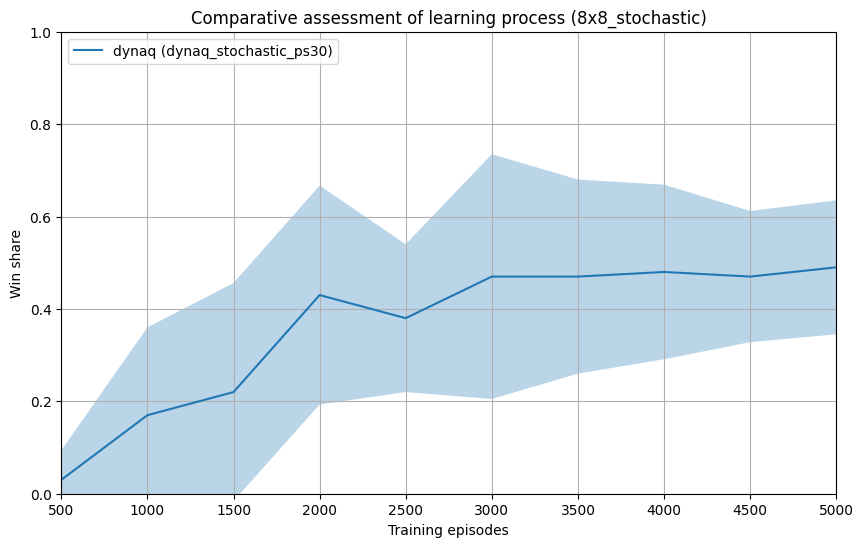

In [37]:
scenario_name = exp_params['scenario_name']
exp_ids = {
    exp_params['algorithm_name']: [exp_params['exp_id']]
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)

### Оценка Dyna-Q


In [38]:
train_eps_num = 4000

load_best_agent_for_train_step(train_eps_num,
                               exp_params['training']['iteration_count'],
                               exp_dirs['training'],
                               dynaq_agent)

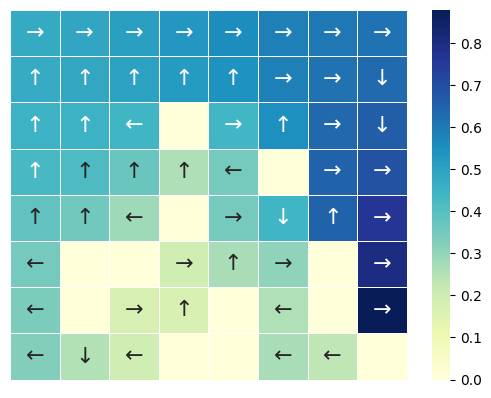

In [39]:
dynaq_agent.display_q_table()

In [40]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)
evaluate_agent(env, dynaq_agent, exp_params, exp_dirs)
env.close()

EPISODE # 1
Agent was defeated ☠️
Number of steps: 100
--------------------------------------------------
EPISODE # 2
Agent reached the Goal 🏆
Number of steps: 73
--------------------------------------------------
EPISODE # 3
Agent reached the Goal 🏆
Number of steps: 95
--------------------------------------------------


In [41]:
show_episode_records(exp_dirs['evaluation'])

## 5. Доп. эксперимент: влияние числа planning-шагов

### Дополнительный запуск Dyna-Q с `planning_steps = 5`


In [42]:
exp_params = {
    'scenario_name': f'{MAP_SIZE}x{MAP_SIZE}_{"stochastic" if STOCHASTIC_ENV else "deterministic"}',
    'algorithm_name': 'dynaq_ps5',
    'exp_id': 'dynaq_stochastic_ps5',
    'seed': 21,
    'training': {
        'iteration_count': 5,
        'episode_count': 5000,
        'learning_rate': 0.05,
        'gamma': 0.99,
        'epsilon': 1.0,
        'epsilon_min': 0.01,
        'epsilon_decay_rate': 0.99995,
        'planning_steps': 5
    },
    'validation': {
        'validate_agent_every_n_eps': 500,
        'episode_count': 10
    },
    'evaluation': {
        'episode_count': 3
    }
}

exp_dirs = create_exp_dirs(scenarios_dir, exp_params)
save_exp_params(exp_params, exp_dirs['exp'])


TRAINING ITERATION # 1 / 5
EPISODE # 500 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.975
--------------------------------------------------
EPISODE # 1000 / 5000
Win share (10 eps): 0.0
Avg step count (10 eps): 100.0
Aget exploration level (epsilon): 0.951
--------------------------------------------------
EPISODE # 1500 / 5000
Win share (10 eps): 0.1
Avg step count (10 eps): 54.1
Aget exploration level (epsilon): 0.928
--------------------------------------------------
EPISODE # 2000 / 5000
Win share (10 eps): 0.3
Avg step count (10 eps): 85.3
Aget exploration level (epsilon): 0.905
--------------------------------------------------
EPISODE # 2500 / 5000
Win share (10 eps): 0.2
Avg step count (10 eps): 60.2
Aget exploration level (epsilon): 0.882
--------------------------------------------------
EPISODE # 3000 / 5000
Win share (10 eps): 0.1
Avg step count (10 eps): 45.6
Aget exploration level (epsilon): 0.861
---------------------

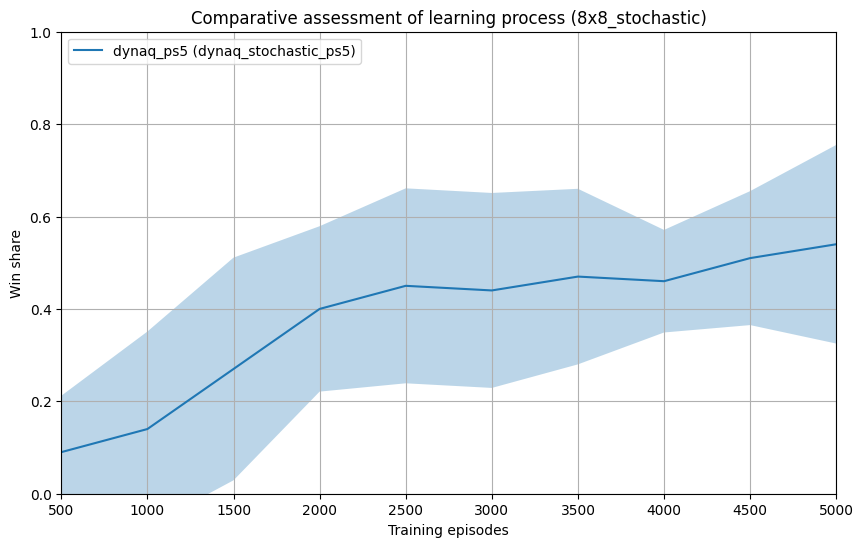

In [43]:
env = create_environment(map_size=MAP_SIZE, stochastic_env=STOCHASTIC_ENV)

for iter_num in range(1, exp_params['training']['iteration_count'] + 1):
    print(f'TRAINING ITERATION # {iter_num} / {exp_params["training"]["iteration_count"]}')
    dynaq_agent_ps5 = DynaQAgent(env, StochasticEnvModel, exp_params)
    train_agent(env, dynaq_agent_ps5, exp_params, exp_dirs, False)

scenario_name = exp_params['scenario_name']
exp_ids = {
    exp_params['algorithm_name']: [exp_params['exp_id']]
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)
env.close()


### Сравнение Dyna-Q при разных значениях `planning_steps`


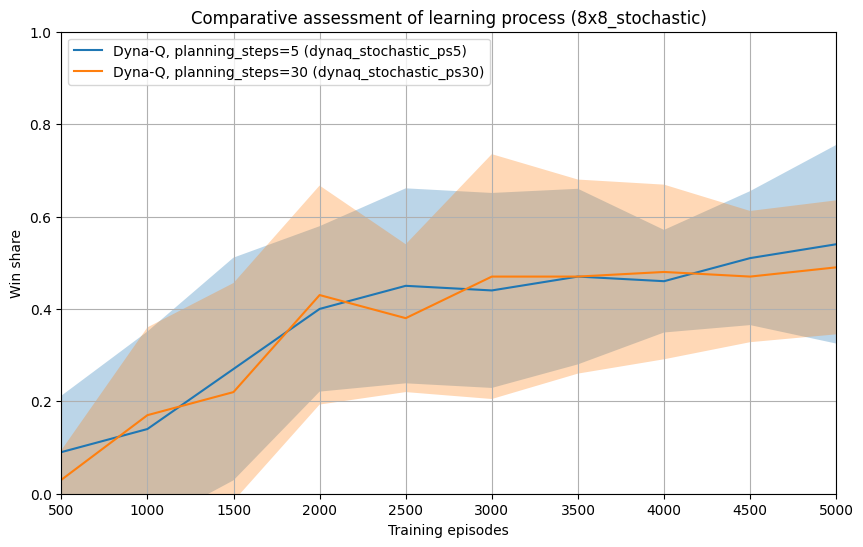

In [44]:
scenario_name = '8x8_stochastic'
exp_ids = {
    'Dyna-Q, planning_steps=5': {
        'algorithm_name': 'dynaq_ps5',
        'exp_ids': ['dynaq_stochastic_ps5']
    },
    'Dyna-Q, planning_steps=30': {
        'algorithm_name': 'dynaq',
        'exp_ids': ['dynaq_stochastic_ps30']
    }
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)

Вариант с 5-ю шагами планирования тоже достаточно хорошо учится, но результаты сильнее колеблются между итерациями, чем в варианте с 30-ю шагами. То есть уменьшение числа шагов планирование обучение не ломает, но оно становится менее предсказуемым.

## 6. Сравнение Q-learning и Dyna-Q



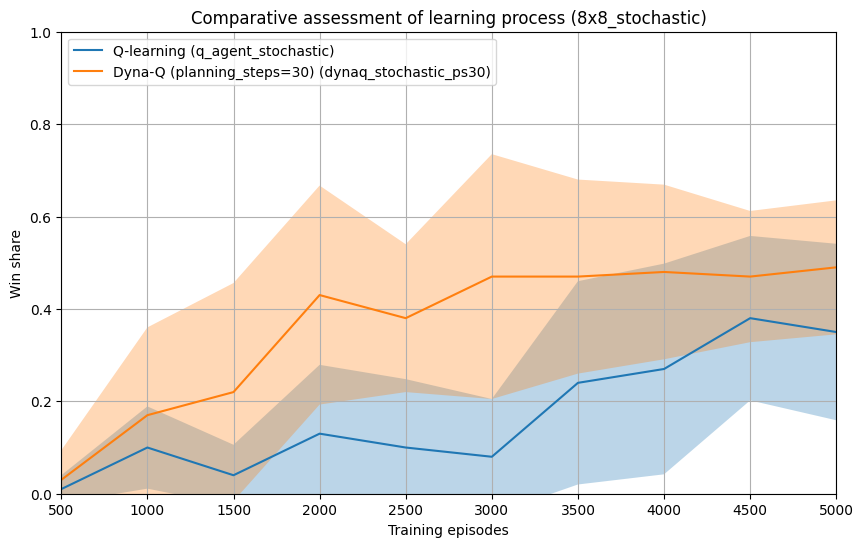

In [45]:
scenario_name = '8x8_stochastic'
exp_ids = {
    'Q-learning': {
        'algorithm_name': 'qtable',
        'exp_ids': ['q_agent_stochastic']
    },
    'Dyna-Q (planning_steps=30)': {
        'algorithm_name': 'dynaq',
        'exp_ids': ['dynaq_stochastic_ps30']
    }
}

display_validation_plot(scenarios_dir, scenario_name, exp_ids)

По графикам обучения Dyna-Q (30 шагов планирования) выглядит заметно сильнее, чем Q-learning, учится быстрее и эффективнее. Но при этом на валидации результаты были похожи: и Q-learning, и Dyna-Q дошли до цели в 2-х эпизодах из 3-х.

## 7. Выводы

Случайный агент ожидаемо не решает задачу: в трёх эпизодах на валидации он ни разу не достиг цели. Для стохастической среды его явно недостаточно.

Q-learning обучается нестабильно, заметный рост качества начинается поздно и в целом при обучении прогресс сильно "скачет". Тем не менее на валидации загруженный агент с лучшим результатом смог дойти до цели в 2-х эпизодах из 3-х.

Dyna-Q со стохастической моделью среды на этапе обучения показывает более сильную динамику. В конце обучения он достиг более высокого показателя win share по сравнению с Q-learning, и в целом процесс обучения шел стабильнее. На валидации агент с Dyna-Q тоже достиг цели в 2-х эпизодах из 3-х, так что в целом в данном эксперименте Dyna-Q обыграл Q-learning больше в самом процессе обучения, чем в результатах. 

Предполагаю, что с увеличением числа итераций обучения разрыв в метриках будет нарастать, и в итоге Dyna-Q сможет чаще достигать цели, чем агент с Q-learning, но проверка этой гипотезы пока остается за рамками эксперимента.

Был проведен дополнительный эксперимент с уменьшенным числом шагов планирования (5), который показал, что с небольшим числом шагов планирования агент все еще достаточно неплохо учится, но обучение становится менее стабильным.